## Klasy z poprzednich zadań

**QLearningAgent**

In [19]:
from collections import defaultdict
import random

class QLearningAgent:
    def __init__(self, alpha, epsilon, discount, get_legal_actions):
        """
        Q-Learning Agent
        based on https://inst.eecs.berkeley.edu/~cs188/sp19/projects.html
        Instance variables you have access to
          - self.epsilon (exploration prob)
          - self.alpha (learning rate)
          - self.discount (discount rate aka gamma)

        Functions you should use
          - self.get_legal_actions(state) {state, hashable -> list of actions, each is hashable}
            which returns legal actions for a state
          - self.get_qvalue(state,action)
            which returns Q(state,action)
          - self.set_qvalue(state,action,value)
            which sets Q(state,action) := value
        !!!Important!!!
        Note: please avoid using self._qValues directly.
            There's a special self.get_qvalue/set_qvalue for that.
        """

        self.get_legal_actions = get_legal_actions
        self._qvalues = defaultdict(lambda: defaultdict(lambda: 0))
        self.alpha = alpha
        self.epsilon = epsilon
        self.discount = discount

    def get_qvalue(self, state, action):
        """ Returns Q(state,action) """
        return self._qvalues[state][action]

    def set_qvalue(self, state, action, value):
        """ Sets the Qvalue for [state,action] to the given value """
        self._qvalues[state][action] = value

    #---------------------START OF YOUR CODE---------------------#

    def get_value(self, state):
        """
        Compute your agent's estimate of V(s) using current q-values
        V(s) = max_over_action Q(state,action) over possible actions.
        Note: please take into account that q-values can be negative.
        """
        possible_actions = self.get_legal_actions(state)

        # If there are no legal actions, return 0.0
        if len(possible_actions) == 0:
            return 0.0
        
        values = []
        for action in possible_actions:
            q_value = self.get_qvalue(state, action)
            values.append(q_value)

        max_value = max(values) if values else 0.0

        #
        # INSERT CODE HERE to get maximum possible value for a given state
        #
        

        return max_value

    def update(self, state, action, reward, next_state):
        """
        You should do your Q-Value update here:
           Q(s,a) := (1 - alpha) * Q(s,a) + alpha * (r + gamma * V(s'))
        """

        # agent parameters
        gamma = self.discount
        learning_rate = self.alpha

        current_qvalue = self.get_qvalue(state, action)
        next_value = self.get_value(next_state)

        updated_qvalue = (1 - learning_rate) * current_qvalue + learning_rate * (reward + gamma * next_value)
        self.set_qvalue(state, action, updated_qvalue)

        #
        # INSERT CODE HERE to update value for the given state and action
        #
        


    def get_best_action(self, state):
        """
        Compute the best action to take in a state (using current q-values).
        """
        possible_actions = self.get_legal_actions(state)

        # If there are no legal actions, return None
        if len(possible_actions) == 0:
            return None
        
        possible_actions_qvalues = []
        for action in possible_actions:
            q_value = self.get_qvalue(state, action)
            possible_actions_qvalues.append(q_value)
        
        max_qvalue = max(possible_actions_qvalues)

        best_actions = []

        for i in range(len(possible_actions)):
            a = possible_actions[i]
            q = possible_actions_qvalues[i]
            if q == max_qvalue:
                best_actions.append(a)

        best_action = random.choice(best_actions)
        
        #
        # INSERT CODE HERE to get best possible action in a given state (remember to break ties randomly)
        #

        return best_action

    def get_action(self, state):
        """
        Compute the action to take in the current state, including exploration.
        With probability self.epsilon, we should take a random action.
            otherwise - the best policy action (self.get_best_action).

        Note: To pick randomly from a list, use random.choice(list).
              To pick True or False with a given probablity, generate uniform number in [0, 1]
              and compare it with your probability
        """

        # Pick Action
        possible_actions = self.get_legal_actions(state)

        # If there are no legal actions, return None
        if len(possible_actions) == 0:
            return None

        # agent parameters:
        epsilon = self.epsilon

        prob = random.uniform(0, 1)
        if prob < epsilon:
            chosen_action = random.choice(possible_actions)
        else:
            chosen_action = self.get_best_action(state)

        #
        # INSERT CODE HERE to get action in a given state (according to epsilon greedy algorithm)
        #        

        return chosen_action

    def turn_off_learning(self):
        """
        Function turns off agent learning.
        """
        self.epsilon = 0
        self.alpha = 0


**SARSAAgent**

In [20]:
class SARSAAgent:
    def __init__(self, alpha, epsilon, discount, get_legal_actions):
        """
        Q-Learning Agent
        based on https://inst.eecs.berkeley.edu/~cs188/sp19/projects.html
        Instance variables you have access to
          - self.epsilon (exploration prob)
          - self.alpha (learning rate)
          - self.discount (discount rate aka gamma)

        Functions you should use
          - self.get_legal_actions(state) {state, hashable -> list of actions, each is hashable}
            which returns legal actions for a state
          - self.get_qvalue(state,action)
            which returns Q(state,action)
          - self.set_qvalue(state,action,value)
            which sets Q(state,action) := value
        !!!Important!!!
        Note: please avoid using self._qValues directly.
            There's a special self.get_qvalue/set_qvalue for that.
        """

        self.get_legal_actions = get_legal_actions
        self._qvalues = defaultdict(lambda: defaultdict(lambda: 0))
        self.alpha = alpha
        self.epsilon = epsilon
        self.discount = discount

    def get_qvalue(self, state, action):
        """ Returns Q(state,action) """
        return self._qvalues[state][action]

    def set_qvalue(self, state, action, value):
        """ Sets the Qvalue for [state,action] to the given value """
        self._qvalues[state][action] = value

    # ---------------------START OF YOUR CODE---------------------#

    def get_value(self, state):
        """
        Compute your agent's estimate of V(s) using current q-values
        V(s) = max_over_action Q(state,action) over possible actions.
        Note: please take into account that q-values can be negative.
        """
        possible_actions = self.get_legal_actions(state)

        # If there are no legal actions, return 0.0
        if len(possible_actions) == 0:
            return 0.0
        
        values = []
        for action in possible_actions:
            q_value = self.get_qvalue(state, action)
            values.append(q_value)

        #
        # INSERT CODE HERE to get maximum possible value for a given state
        #

        return max(values)

    def update(self, state, action, reward, next_state):
        """
        You should do your Q-Value update here:
           Q(s,a) := (1 - alpha) * Q(s,a) + alpha * (r + gamma * Q(s', a'))
        """

        # agent parameters
        gamma = self.discount
        learning_rate = self.alpha

        current_qvalue = self.get_qvalue(state, action)
        next_action = self.get_best_action(next_state)
        next_qvalue = self.get_qvalue(next_state, next_action)

        updated_qvalue = (1 - learning_rate) * current_qvalue + learning_rate * (reward + gamma * next_qvalue)
        self.set_qvalue(state, action, updated_qvalue)

        #
        # INSERT CODE HERE to update value for the given state and action
        #
       

        # function returns selected action for next state
        return next_action

    def get_best_action(self, state):
        """
        Compute the best action to take in a state (using current q-values).
        """
        possible_actions = self.get_legal_actions(state)

        # If there are no legal actions, return None
        if len(possible_actions) == 0:
            return None
        
        possible_actions_qvalues = []
        for action in possible_actions:
            q_value = self.get_qvalue(state, action)
            possible_actions_qvalues.append(q_value)

        max_qvalue = max(possible_actions_qvalues)

        best_actions = []
        for i in range(len(possible_actions)):
            a = possible_actions[i]
            q = possible_actions_qvalues[i]
            if q == max_qvalue:
                best_actions.append(a)
        
        if len(best_actions) == 0:
            return None
        
        best_action = random.choice(best_actions)

        #
        # INSERT CODE HERE to get best possible action in a given state (remember to break ties randomly)
        #

        return best_action

    def get_action(self, state):
        """
        Compute the action to take in the current state, including exploration.
        With probability self.epsilon, we should take a random action.
            otherwise - the best policy action (self.get_best_action).

        Note: To pick randomly from a list, use random.choice(list).
              To pick True or False with a given probablity, generate uniform number in [0, 1]
              and compare it with your probability
        """

        # Pick Action
        possible_actions = self.get_legal_actions(state)

        # If there are no legal actions, return None
        if len(possible_actions) == 0:
            return None

        # agent parameters:
        epsilon = self.epsilon

        prob = random.uniform(0, 1)
        if prob < epsilon:
            chosen_action = random.choice(possible_actions)
        else:
            chosen_action = self.get_best_action(state)

        #
        # INSERT CODE HERE to get action in a given state (according to epsilon greedy algorithm)
        #        

        return chosen_action

    def turn_off_learning(self):
        """
        Function turns off agent learning.
        """
        self.epsilon = 0
        self.alpha = 0

**ExpectedSARSAAgent**

In [21]:
class ExpectedSARSAAgent:
    def __init__(self, alpha, epsilon, discount, get_legal_actions):
        """
        Q-Learning Agent
        based on https://inst.eecs.berkeley.edu/~cs188/sp19/projects.html
        Instance variables you have access to
          - self.epsilon (exploration prob)
          - self.alpha (learning rate)
          - self.discount (discount rate aka gamma)

        Functions you should use
          - self.get_legal_actions(state) {state, hashable -> list of actions, each is hashable}
            which returns legal actions for a state
          - self.get_qvalue(state,action)
            which returns Q(state,action)
          - self.set_qvalue(state,action,value)
            which sets Q(state,action) := value
        !!!Important!!!
        Note: please avoid using self._qValues directly.
            There's a special self.get_qvalue/set_qvalue for that.
        """

        self.get_legal_actions = get_legal_actions
        self._qvalues = defaultdict(lambda: defaultdict(lambda: 0))
        self.alpha = alpha
        self.epsilon = epsilon
        self.discount = discount

    def get_qvalue(self, state, action):
        """ Returns Q(state,action) """
        return self._qvalues[state][action]

    def set_qvalue(self, state, action, value):
        """ Sets the Qvalue for [state,action] to the given value """
        self._qvalues[state][action] = value

    #---------------------START OF YOUR CODE---------------------#

    def get_value(self, state):
        """
        Compute your agent's estimate of V(s) using current q-values
        V(s) = max_over_action Q(state,action) over possible actions.
        Note: please take into account that q-values can be negative.
        """
        possible_actions = self.get_legal_actions(state)

        # If there are no legal actions, return 0.0
        if len(possible_actions) == 0:
            return 0.0
        
        values = []
        for action in possible_actions:
            q_value = self.get_qvalue(state, action)
            values.append(q_value)

        max_value = max(values) if values else 0.0

        #
        # INSERT CODE HERE to get maximum possible value for a given state
        #

        return max_value

    def update(self, state, action, reward, next_state):
        """
        You should do your Q-Value update here:
           Q(s,a) := (1 - alpha) * Q(s,a) + alpha * (r + gamma * \sum_a \pi(a|s') Q(s', a))
        """

        # agent parameters
        gamma = self.discount
        learning_rate = self.alpha

        current_qvalue = self.get_qvalue(state, action)
        possible_actions = self.get_legal_actions(next_state)

        expected_qvalue = 0.0
        for a in possible_actions:
            q_value = self.get_qvalue(next_state, a)
            prob_a = self.epsilon / len(possible_actions)

            if a == self.get_best_action(next_state):
                prob_a += (1 - self.epsilon)

            expected_qvalue += prob_a * q_value

        updated_qvalue = (1 - learning_rate) * current_qvalue + learning_rate * (reward + gamma * expected_qvalue)
        self.set_qvalue(state, action, updated_qvalue)

        #
        # INSERT CODE HERE to update value for the given state and action
        #


    def get_best_action(self, state):
        """
        Compute the best action to take in a state (using current q-values).
        """
        possible_actions = self.get_legal_actions(state)

        # If there are no legal actions, return None
        if len(possible_actions) == 0:
            return None
        
        possible_actions_qvalues = []
        for action in possible_actions:
            q_value = self.get_qvalue(state, action)
            possible_actions_qvalues.append(q_value)
        
        max_qvalue = max(possible_actions_qvalues)
        best_actions = []
        for i in range(len(possible_actions)):
            a = possible_actions[i]
            q = possible_actions_qvalues[i]
            if q == max_qvalue:
                best_actions.append(a)

        best_action = random.choice(best_actions)

        #
        # INSERT CODE HERE to get best possible action in a given state (remember to break ties randomly)
        #

        return best_action

    def get_action(self, state):
        """
        Compute the action to take in the current state, including exploration.
        With probability self.epsilon, we should take a random action.
            otherwise - the best policy action (self.get_best_action).

        Note: To pick randomly from a list, use random.choice(list).
              To pick True or False with a given probablity, generate uniform number in [0, 1]
              and compare it with your probability
        """

        # Pick Action
        possible_actions = self.get_legal_actions(state)

        # If there are no legal actions, return None
        if len(possible_actions) == 0:
            return None

        # agent parameters:
        epsilon = self.epsilon

        prob = random.uniform(0, 1)
        if prob < epsilon:
            chosen_action = random.choice(possible_actions)
        else:
            chosen_action = self.get_best_action(state) 

        #
        # INSERT CODE HERE to get action in a given state (according to epsilon greedy algorithm)
        #        

        return chosen_action

    def turn_off_learning(self):
        """
        Function turns off agent learning.
        """
        self.epsilon = 0
        self.alpha = 0
    

<>:67: SyntaxWarning: invalid escape sequence '\s'
<>:67: SyntaxWarning: invalid escape sequence '\s'
C:\Users\Filip\AppData\Local\Temp\ipykernel_14920\3366155398.py:67: SyntaxWarning: invalid escape sequence '\s'
  Q(s,a) := (1 - alpha) * Q(s,a) + alpha * (r + gamma * \sum_a \pi(a|s') Q(s', a))


# Laboratorium 3 (4 pkt.)

Celem trzeciego laboratorium jest zapoznanie się oraz zaimplementowanie algorytmów uczenia aktywnego. Zaimplementowane algorytmy będą testowane z wykorzystaniem wcześniej przygotowanych środowisk.

Dołączenie standardowych bibliotek

In [22]:
import random
import matplotlib.pyplot as plt
import numpy as np

Dołączenie bibliotek ze środowiskami

In [23]:
from env.dqnSimpleMDP import dqnSimpleMDP
from env.CliffWorldMDP import CliffWorld


## Zadanie 1 - SARSA($\lambda$) (1 pkt.)

<p style='text-align: justify;'>
Celem ćwiczenia jest zaimplementowanie algorytmu SARSA($\lambda$). Algorytm aktualizuje funkcję wartości stanu-akcji dla każdej odwiedzonej pary stan-akcja zgodnie ze wzorem:

$$
Q_{t + 1}(s, a) = Q_t(s, a) + \alpha \delta_t E_t(s, a)
$$

gdzie:
    
- $\delta_t = r_{t + 1} + \gamma Q_t(s_{t + 1}, a_{t + 1}) - Q_t(s_{t}, a_{t})$,
    
- $E_t(s, a)$ - ślad dla pary stan - akcja w chwili czasowej $t$, zwiększany o $1$ w chwili odwiedzenia danego stanu.

</p>

In [24]:
import random
from collections import defaultdict


class SARSALambdaAgent:
    def __init__(self, alpha, epsilon, discount, get_legal_actions, lambda_value):
        """
        SARSA Lambda Agent
        based on https://inst.eecs.berkeley.edu/~cs188/sp19/projects.html
        Instance variables you have access to
          - self.epsilon (exploration prob)
          - self.alpha (learning rate)
          - self.discount (discount rate aka gamma)

        Functions you should use
          - self.get_legal_actions(state) {state, hashable -> list of actions, each is hashable}
            which returns legal actions for a state
          - self.get_qvalue(state,action)
            which returns Q(state,action)
          - self.set_qvalue(state,action,value)
            which sets Q(state,action) := value
        !!!Important!!!
        Note: please avoid using self._qValues directly.
            There's a special self.get_qvalue/set_qvalue for that.
        """

        self.get_legal_actions = get_legal_actions
        self._qvalues = defaultdict(lambda: defaultdict(lambda: 0))
        self._evalues = defaultdict(lambda: defaultdict(lambda: 0))
        self.alpha = alpha
        self.epsilon = epsilon
        self.discount = discount
        self.lambda_value = lambda_value

    def get_qvalue(self, state, action):
        """ Returns Q(state,action) """
        return self._qvalues[state][action]

    def set_qvalue(self, state, action, value):
        """ Sets the Qvalue for [state,action] to the given value """
        self._qvalues[state][action] = value

    def reset(self):
        self._evalues = defaultdict(lambda: defaultdict(lambda: 0))

    # ---------------------START OF YOUR CODE---------------------#

    def get_value(self, state):
        """
        Compute your agent's estimate of V(s) using current q-values
        V(s) = max_over_action Q(state,action) over possible actions.
        Note: please take into account that q-values can be negative.
        """
        possible_actions = self.get_legal_actions(state)

        # If there are no legal actions, return 0.0
        if len(possible_actions) == 0:
            return 0.0
        
        values = []
        for action in possible_actions:
            q_value = self.get_qvalue(state, action)
            values.append(q_value)

        #
        # INSERT CODE HERE to get maximum possible value for a given state
        #


        return max(values)

    def update(self, state, action, reward, next_state):
        """
        You should do your SARSA-Lambda update here:
        """

        # agent parameters
        gamma = self.discount
        learning_rate = self.alpha
        next_action = self.get_action(next_state)

        error = reward + gamma * self.get_qvalue(next_state, next_action) - self.get_qvalue(state, action)
        self._evalues[state][action] += 1

        for s in self._qvalues:
            for a in self.get_legal_actions(s):
                old_q = self.get_qvalue(s, a)
                new_q = old_q + learning_rate * error * self._evalues[s][a]
                self.set_qvalue(s, a, new_q)
                self._evalues[s][a] *= (1-learning_rate) * gamma * self.lambda_value
          
        #
        # INSERT CODE HERE to update value in the state for the action 
        #

        return next_action

    def get_best_action(self, state):
        """
        Compute the best action to take in a state (using current q-values).
        """
        possible_actions = self.get_legal_actions(state)

        # If there are no legal actions, return None
        if len(possible_actions) == 0:
            return None
        

        possible_actions_qvalues = []
        for action in possible_actions:
            q_value = self.get_qvalue(state, action)
            possible_actions_qvalues.append(q_value)

        max_qvalue = max(possible_actions_qvalues)
        best_actions = []
        for i in range(len(possible_actions)):
            a = possible_actions[i]
            q = possible_actions_qvalues[i]
            if q == max_qvalue:
                best_actions.append(a)

        best_action = random.choice(best_actions)

        #
        # INSERT CODE HERE to get best action for a given state
        #
        #

        return best_action

    def get_action(self, state):
        """
        Compute the action to take in the current state, including exploration.
        With probability self.epsilon, we should take a random action.
            otherwise - the best policy action (self.get_best_action).

        Note: To pick randomly from a list, use random.choice(list).
              To pick True or False with a given probablity, generate uniform number in [0, 1]
              and compare it with your probability
        """

        # Pick Action
        possible_actions = self.get_legal_actions(state)

        # If there are no legal actions, return None
        if len(possible_actions) == 0:
            return None

        # agent parameters:
        epsilon = self.epsilon

        prob = random.uniform(0, 1)
        if prob < epsilon:
            chosen_action = random.choice(possible_actions)
        else:
            chosen_action = self.get_best_action(state)

        #
        # INSERT CODE HERE to get action in a given state (according to epsilon greedy algorithm)
        #        

        return chosen_action

    def turn_off_learning(self):
        self.epsilon = 0
        self.alpha = 0

    def display_qvalues(self):
        for s in self._qvalues:
            print("State: " + str(s) + " " + str(self._qvalues[s]))


Czas nauczyć agenta poruszania się po dowolnym środowisku:

In [25]:
def play_and_train(env, agent):
    """
    This function should
    - run a full game, actions given by agent's e-greedy policy
    - train agent using agent.update(...) whenever it is possible
    - return total reward
    """
    total_reward = 0.0
    state = env.reset()

    done = False

    agent.reset()
    action = agent.get_action(state)
    
    while not done:
        # get agent to pick action given state state.

        next_state, reward, done, _ = env.step(action)

        next_action = agent.update(state, action, reward, next_state)
        action = next_action

        # train (update) agent for state

        state = next_state
        total_reward += reward
        if done:
            break
    return total_reward

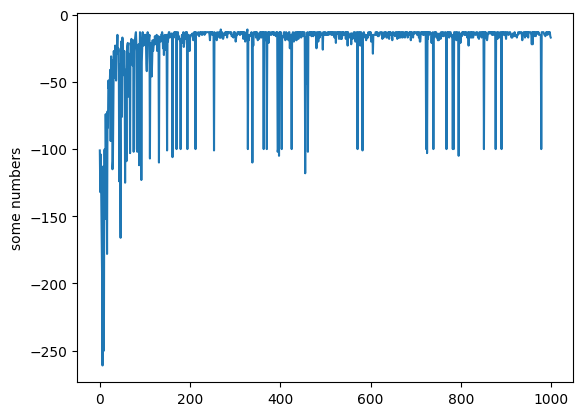

In [26]:
environment = CliffWorld()
agent = SARSALambdaAgent(alpha=0.1, epsilon=0.1, discount=0.99,
                   get_legal_actions=environment.get_possible_actions, lambda_value = 0.5)

rewards = []
for i in range(1000):
    rewards.append(play_and_train(environment, agent))

plt.plot(rewards)
plt.ylabel('some numbers')
plt.show()

## Zadanie 2 - Double Q-Learning

<p style='text-align: justify;'>
Celem ćwiczenia jest zaimplementowanie algorytmu Double Q-Learning. Algorytm aktualizuje funkcję wartości stanu-akcji zgodnie ze wzorami:

$$
Q_1(s_t, a_t) = Q_1(s_t, a_t) + \alpha[r_{t+1} + \gamma Q_2(s_{t + 1}, \arg\max_a(Q_1(s_{t + 1}, a))) - Q_1(s_t, a_t)]
$$

$$
Q_2(s_t, a_t) = Q_2(s_t, a_t) + \alpha[r_{t+1} + \gamma Q_1(s_{t + 1}, \arg\max_a(Q_2(s_{t + 1}, a))) - Q_2(s_t, a_t)]
$$

z prawdopodobieństwem wyboru każdej z opcji równym 50%.
</p>

In [27]:
import random
from collections import defaultdict


class DQLearningAgent:
    def __init__(self, alpha, epsilon, discount, get_legal_actions):
        """
        Double Q-Learning Agent
        based on https://inst.eecs.berkeley.edu/~cs188/sp19/projects.html
        Instance variables you have access to
          - self.epsilon (exploration prob)
          - self.alpha (learning rate)
          - self.discount (discount rate aka gamma)
        """

        self.get_legal_actions = get_legal_actions
        self._qvaluesA = defaultdict(lambda: defaultdict(lambda: 0))
        self._qvaluesB = defaultdict(lambda: defaultdict(lambda: 0))
        self.alpha = alpha
        self.epsilon = epsilon
        self.discount = discount
        
    def get_qvalue(self, state, action):
        """ Returns Q(state,action) """
        return self._qvaluesA[state][action] + self._qvaluesB[state][action] 


    #---------------------START OF YOUR CODE---------------------#

    def get_value_chose(self, state, action, isA = True):
        if isA:
            return self._qvaluesA[state][action]
        return self._qvaluesB[state][action]

    def get_best_action(self, state, isA = True):
        """
        Compute the best action to take in a state (using current q-values).
        """
        possible_actions = self.get_legal_actions(state)

        # If there are no legal actions, return None
        if len(possible_actions) == 0:
            return None
        
        possible_actions_qvalues = []
        for action in possible_actions:
            q_value = self.get_value_chose(state, action, isA)
            possible_actions_qvalues.append(q_value)
        
        max_qvalue = max(possible_actions_qvalues)
        best_actions = []
        for i in range(len(possible_actions)):
            a = possible_actions[i]
            q = possible_actions_qvalues[i]
            if q == max_qvalue:
                best_actions.append(a)

        best_action = random.choice(best_actions)

        #
        # INSERT CODE HERE to get best possible action in a given state (remember to break ties randomly)
        #

        return best_action

    def update(self, state, action, reward, next_state):
        """
        You should do your Q-Value update here
        """

        # agent parameters
        gamma = self.discount
        learning_rate = self.alpha

        prob = random.uniform(0, 1)
        if prob < 0.5:
            self._qvaluesA[state][action] += learning_rate * (reward + gamma * self._qvaluesB[next_state][self.get_best_action(next_state, isA=True)] - self._qvaluesA[state][action])
        else:
            self._qvaluesB[state][action] += learning_rate * (reward + gamma * self._qvaluesA[next_state][self.get_best_action(next_state, isA=False)] - self._qvaluesB[state][action])

        #
        # INSERT CODE HERE to update value in the state for the action 
        #


    def get_action(self, state):
        """
        Compute the action to take in the current state, including exploration.
        With probability self.epsilon, we should take a random action.
            otherwise - the best policy action (self.get_best_action).

        Note: To pick randomly from a list, use random.choice(list).
              To pick True or False with a given probablity, generate uniform number in [0, 1]
              and compare it with your probability
        """

        # Pick Action
        possible_actions = self.get_legal_actions(state)

        # If there are no legal actions, return None
        if len(possible_actions) == 0:
            return None

        # agent parameters:
        epsilon = self.epsilon

        prob = random.uniform(0, 1)
        if prob < epsilon:
            chosen_action = random.choice(possible_actions)
        else:
            chosen_action = self.get_best_action(state)

        #
        # INSERT CODE HERE to get action in a given state (according to epsilon greedy algorithm)
        #        

        return chosen_action

    def turn_off_learning(self):
        self.epsilon = 0
        self.alpha = 0


In [28]:
env = dqnSimpleMDP()

max_tests = 10000
n_eps = 300
eps = 0.1
lr = 0.1


left_count_q = np.zeros(n_eps) #count left choices in state A for algorithm Q-Learning
left_count_dq = np.zeros(n_eps) #count left choices in state A for algorithm Double Q-Learning

q_estimate = np.zeros(n_eps) #store value estimation for choosing action left in left choices in state A for algorithm Q-Learning
dq_estimate = np.zeros(n_eps) #store value estimation for choosing action left in left choices in state A for algorithm Double Q-Learning

t = 0
while t < max_tests:

    agent = QLearningAgent(alpha=0.1, epsilon=0.1, discount=1,
                           get_legal_actions=env.get_possible_actions)
    for ep in range(n_eps):
        state = env.reset()
        while True:
            # Select eps-greedy action
            action = agent.get_action(state)

            # Count left actions from A
            if state == 'A' and action == 1:
                left_count_q[ep] += 1

            next_state, reward, done, _ = env.step(action)

            agent.update(state, action, reward, next_state)

            state = next_state
            if done:
                q_estimate[ep] += agent.get_qvalue('A', 1)

                break
    t += 1

q_estimate /= max_tests

In [29]:
t = 0
while t < max_tests:

    agent = DQLearningAgent(alpha=0.1, epsilon=0.1, discount=1,
                            get_legal_actions=env.get_possible_actions)
    for ep in range(n_eps):
        state = env.reset()
        while True:
            # Select eps-greedy action
            action = agent.get_action(state)

            # Count left actions from A
            if state == 'A' and action == 1:
                left_count_dq[ep] += 1

            next_state, reward, done, _ = env.step(action)

            agent.update(state, action, reward, next_state)

            state = next_state
            if done:
                dq_estimate[ep] += agent.get_qvalue('A', 1) / 2

                break
    t += 1

dq_estimate /= max_tests

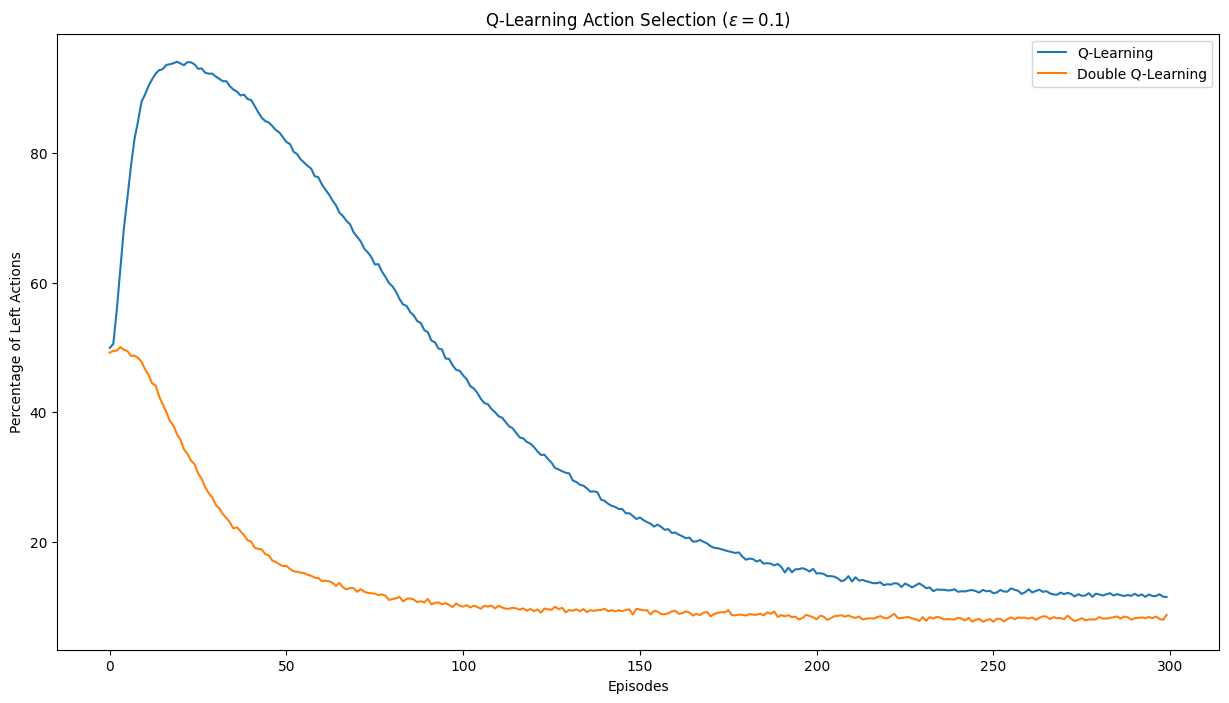

In [30]:
plt.figure(figsize=(15,8))
plt.plot(left_count_q/max_tests*100,
         label='Q-Learning')
plt.plot(left_count_dq/max_tests*100,
         label='Double Q-Learning')
plt.ylabel('Percentage of Left Actions')
plt.xlabel('Episodes')
plt.title(r'Q-Learning Action Selection ($\epsilon=0.1$)')
plt.legend(loc='best')
plt.show()

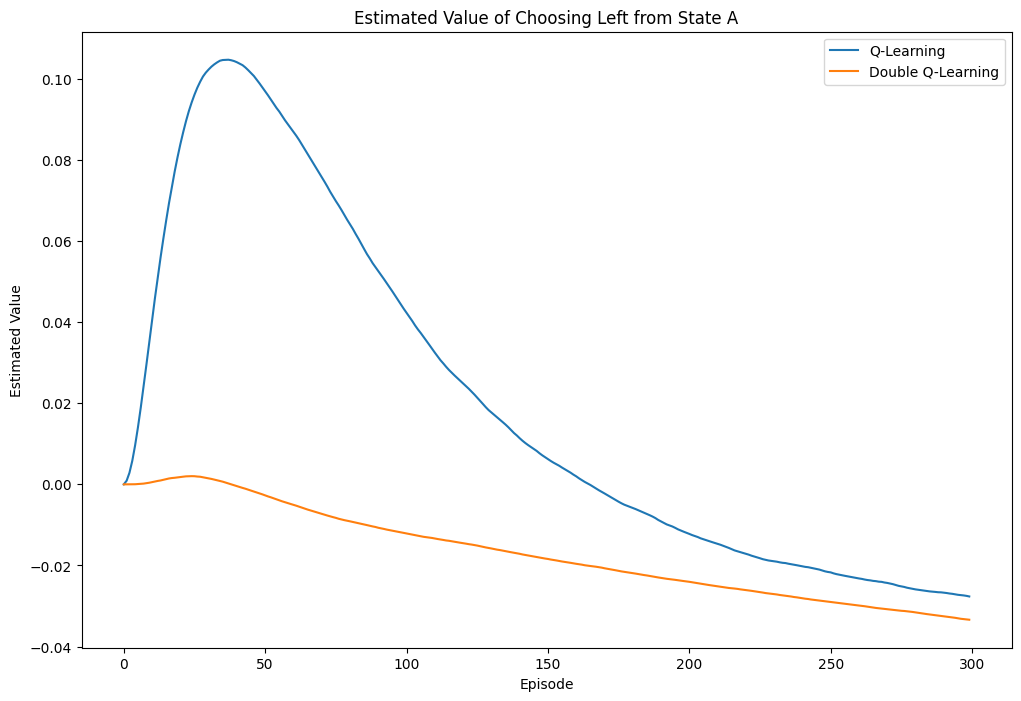

In [31]:
plt.figure(figsize=(12,8))
plt.plot(q_estimate, label='Q-Learning')
plt.plot(dq_estimate, label='Double Q-Learning')

plt.legend()
plt.xlabel('Episode')
plt.ylabel('Estimated Value')
plt.title('Estimated Value of Choosing Left from State A')
plt.show()

## Zadanie 3 

Przetestuj działanie wszystkich zaimplementowanych algorytmów w środowisku dqnSimpleMDP, który algorytm działa najlepiej?

In [32]:
left_count_sarsa = np.zeros(n_eps) #count left choices in state A for algorithm SARSA
left_count_sarsa_lambda = np.zeros(n_eps) #count left choices in state A for
left_count_expected_sarsa = np.zeros(n_eps) #count left choices in state A for algorithm Expected SARSA

sarsa_estimate = np.zeros(n_eps) #store value estimation for choosing action left in left choices in state A for algorithm SARSA
sarsa_lambda_estimate = np.zeros(n_eps) #store value estimation for choosing action left in left choices in state A for algorithm SARSA Lambda
expected_sarsa_estimate = np.zeros(n_eps) #store value estimation for choosing action left in left choices in state A for algorithm Expected SARSA

t = 0
while t < max_tests:

    agent = SARSAAgent(alpha=0.1, epsilon=0.1, discount=1,
                            get_legal_actions=env.get_possible_actions)
    for ep in range(n_eps):
        state = env.reset()
        while True:
            # Select eps-greedy action
            action = agent.get_action(state)

            # Count left actions from A
            if state == 'A' and action == 1:
                left_count_sarsa[ep] += 1

            next_state, reward, done, _ = env.step(action)

            agent.update(state, action, reward, next_state)

            state = next_state
            if done:
                sarsa_estimate[ep] += agent.get_qvalue('A', 1) / 2

                break
    t += 1

sarsa_estimate /= max_tests

In [33]:
t = 0
while t < max_tests:

    agent = SARSALambdaAgent(alpha=0.1, epsilon=0.1, discount=1, lambda_value=0.5,
                            get_legal_actions=env.get_possible_actions)
    for ep in range(n_eps):
        state = env.reset()
        while True:
            # Select eps-greedy action
            action = agent.get_action(state)

            # Count left actions from A
            if state == 'A' and action == 1:
                left_count_sarsa_lambda[ep] += 1

            next_state, reward, done, _ = env.step(action)

            agent.update(state, action, reward, next_state)

            state = next_state
            if done:
                sarsa_lambda_estimate[ep] += agent.get_qvalue('A', 1) / 2

                break
    t += 1

sarsa_lambda_estimate /= max_tests

In [34]:
t = 0
while t < max_tests:

    agent = ExpectedSARSAAgent(alpha=0.1, epsilon=0.1, discount=1,
                            get_legal_actions=env.get_possible_actions)
    for ep in range(n_eps):
        state = env.reset()
        while True:
            # Select eps-greedy action
            action = agent.get_action(state)

            # Count left actions from A
            if state == 'A' and action == 1:
                left_count_expected_sarsa[ep] += 1

            next_state, reward, done, _ = env.step(action)

            agent.update(state, action, reward, next_state)

            state = next_state
            if done:
                expected_sarsa_estimate[ep] += agent.get_qvalue('A', 1) / 2

                break
    t += 1

expected_sarsa_estimate /= max_tests

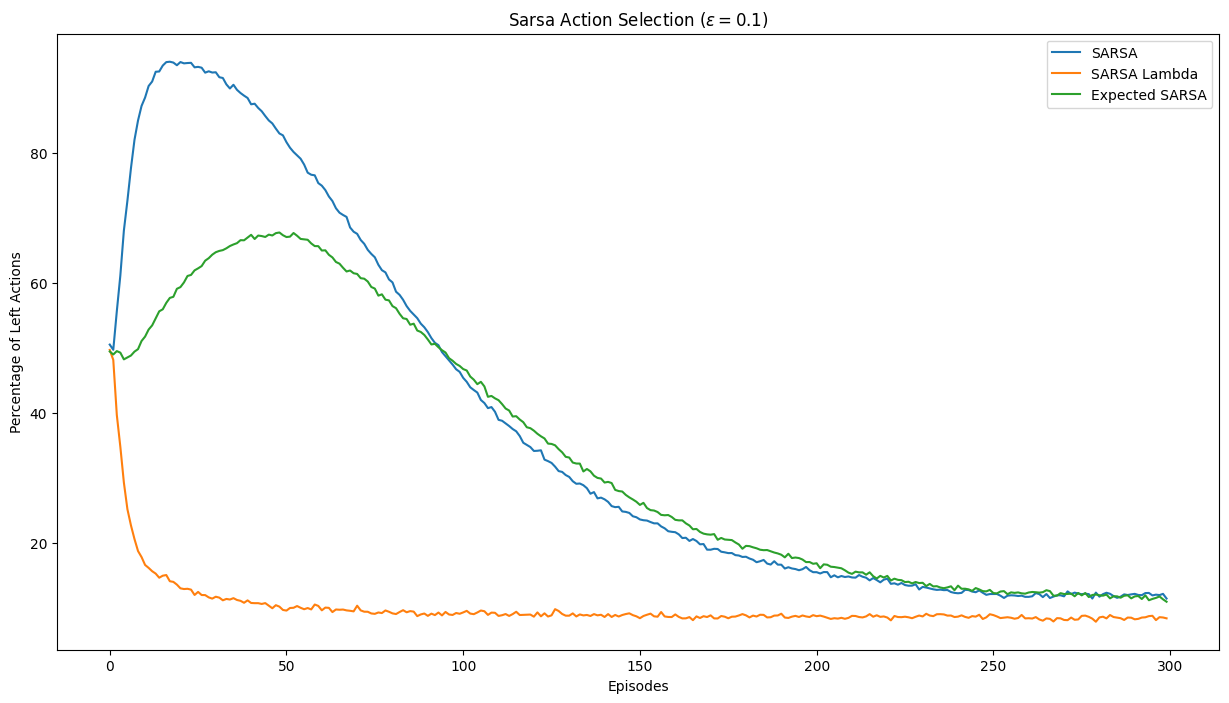

In [35]:
plt.figure(figsize=(15,8))
plt.plot(left_count_sarsa/max_tests*100,
         label='SARSA')
plt.plot(left_count_sarsa_lambda/max_tests*100,
         label='SARSA Lambda')
plt.plot(left_count_expected_sarsa/max_tests*100,
         label='Expected SARSA')
plt.ylabel('Percentage of Left Actions')
plt.xlabel('Episodes')
plt.title(r'Sarsa Action Selection ($\epsilon=0.1$)')
plt.legend(loc='best')
plt.show()

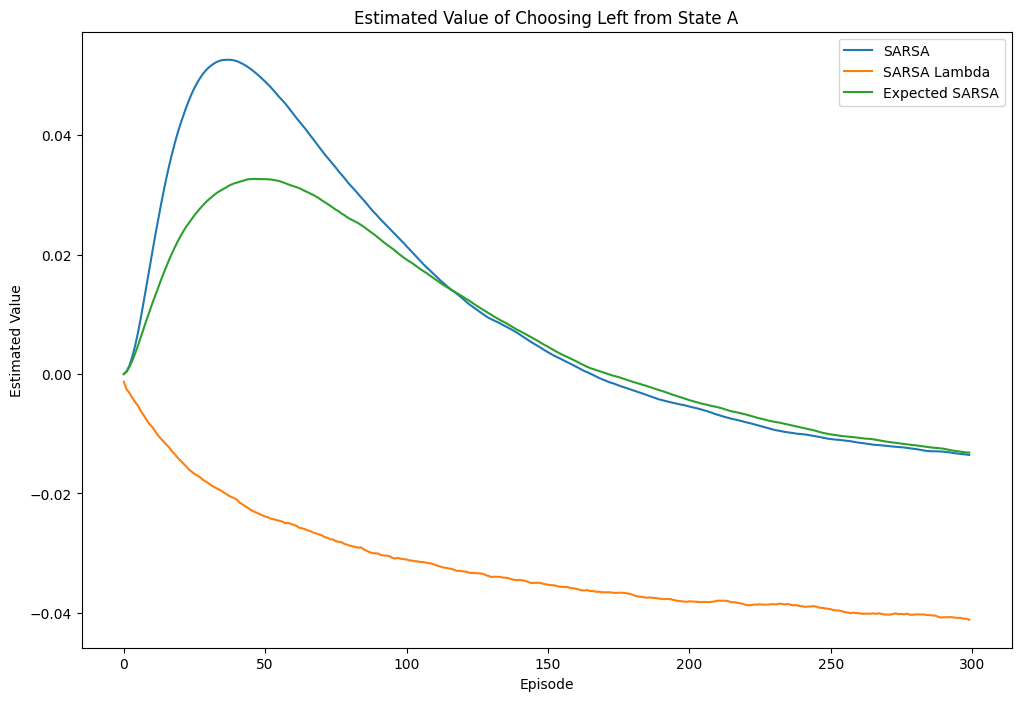

In [36]:
plt.figure(figsize=(12,8))
plt.plot(sarsa_estimate, label='SARSA')
plt.plot(sarsa_lambda_estimate, label='SARSA Lambda')
plt.plot(expected_sarsa_estimate, label='Expected SARSA')

plt.legend()
plt.xlabel('Episode')
plt.ylabel('Estimated Value')
plt.title('Estimated Value of Choosing Left from State A')
plt.show()